---
title: Dataset Characterization
author: Andrei Akopian
date: 2026-02-14
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

# Introduction

A list of details, notes, and concerns regarding the dataset used by the Science Team to train their models, to determine the requirements for the FINCH satelite.

 The dataset `original_data.csv` consists of 1723 datapoints each 210 wavelengths from 400nm to 2490nm in steps of 10. The dataset has several issues: Sometimes one of the fractions of npv, gv, or soil are `0.0`. There is 1 duplicate datapoint in the dataset (`QUE_T1.11.A` and `QUE_T1.11.H`). And around 400 spectra have an anomaly of some form around 1400nm and 1900nm wavelengths. Also, the 1400nm and 1900nm wavelengths behave stragely in general and correlate very poorly with any of the other wavelengths. Also, some of the datapoints are listed as comming from Goleta, California which is an urban city.

The dataset `simpler_data.csv` and `useful_columns_data.csv` are numericaly equivalent to `original_data.csv`, except for some metadata and artifact columns, which were removed.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import mpltern

In [6]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[1]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [7]:
ATMO_DATA = "../../data/isprs_26_only_vza_rows.csv"
LAB_DATA = "../../data/useful_columns_data.csv"

# Lab Data

Open dataset and prepare for operations:

In [8]:
df = helper_functions.open_file(LAB_DATA)

In [9]:
fractions, nr400to2490 = helper_functions.take_subset(df, start=400, end=2490)
_, nr900to1700 = helper_functions.take_subset(df, start=900, end=1700)

### General Overview of Dataset

Below is a heatmap of all the reflectances at different wavelengths.

Attention to the following features:
- a strange "flip" of the graph near 700nm
- a similar strange change in shape near 1400nm
- black stripes and points near zero around 1900nm
  - there is a similar stripe near 1400nm as well, but much less visible
  - something similar (?) near the very last wavelength

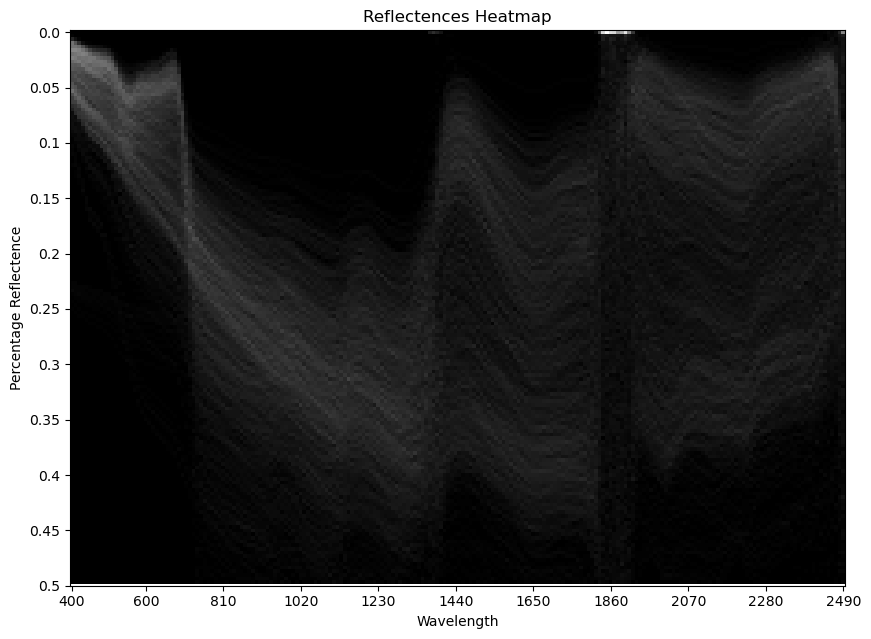

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

resolution = 300
def contrast(array, coef=1.3):
    return array ** (1/coef)
start = 0
end = resolution // 2
xticks = nr400to2490.columns
bins = [1/resolution*i for i in range(0,end+1)]
l = [contrast(np.histogram(nr400to2490[s], bins=bins)[0]) for s in xticks]
np_formatted_l = np.rot90(np.fliplr(np.vstack(l)))

ax.imshow(np_formatted_l, vmin=0, cmap='gray')

ax.set_title("Reflectences Heatmap")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Percentage Reflectence")

n_ticks = 11
idx = np.linspace(0, len(xticks)-1, n_ticks, dtype=int)
ticks = xticks[idx]
plt.xticks(idx, ticks)
idx = np.linspace(0, end, n_ticks, dtype=int)
yticks = idx / resolution
plt.yticks(idx, yticks)

plt.show()

To make the anomalies even clearer, here are some histograms (vertical slices of the heatmap):

The 1370nm graph shows an amount of points near zero, there are similar issues in the next few wavelengths. Also, notice the sudden change in distribution to bimodal (two hills) at 1390nm.

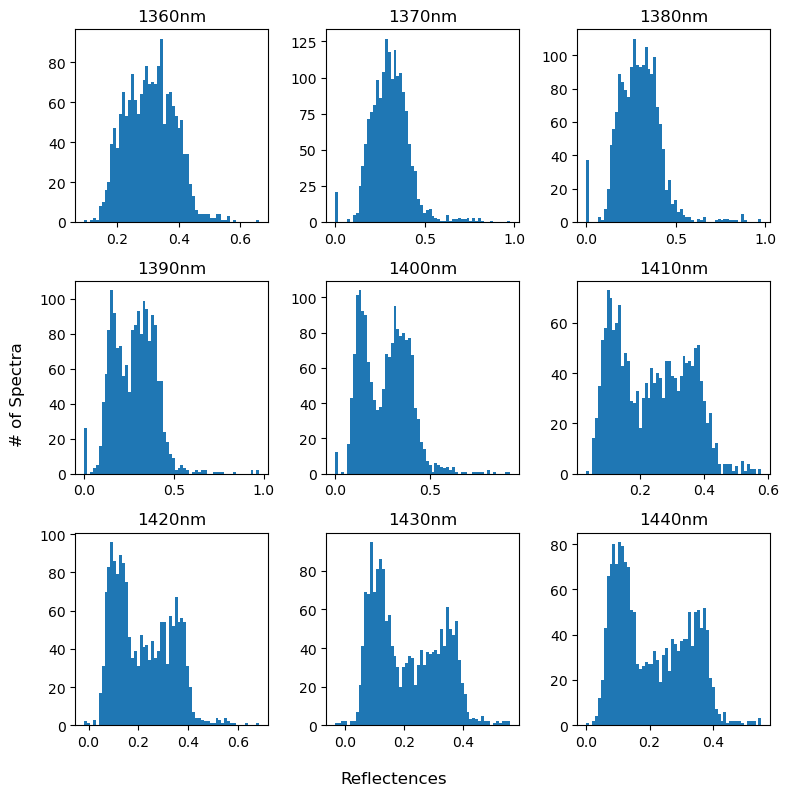

In [13]:
# Create a 2x2 grid of subplots
start = 1360
spectra = [str(i) for i in range(start, start+10*9, 10)]
n_plots = len(spectra)
row = int(np.ceil(np.sqrt(n_plots)))
fig, axs = plt.subplots(row, row, figsize=(8, 8))

fig.supxlabel("Reflectences")
fig.supylabel("# of Spectra")

for i, s in enumerate(spectra):
    px = i % row 
    py = i // row
    axs[py, px].hist(nr400to2490[s],bins=60)
    axs[py, px].set_title(s+'nm')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Here is the "flip" near 700nm visualized. Again observe the change in distribution.

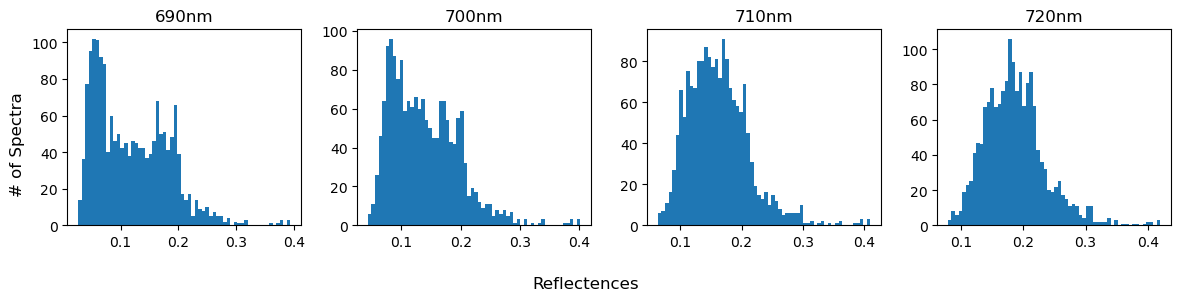

In [14]:
# Create a 2x2 grid of subplots
start = 690
spectra = [str(i) for i in range(start, start+10*4, 10)]
n_plots = len(spectra)
fig, axs = plt.subplots(1, n_plots, figsize=(12, 3))

fig.supxlabel("Reflectences")
fig.supylabel("# of Spectra")

for i, s in enumerate(spectra):
    axs[i].hist(nr400to2490[s],bins=60)
    axs[i].set_title(s+'nm')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

And the 1860nm region anomaly:

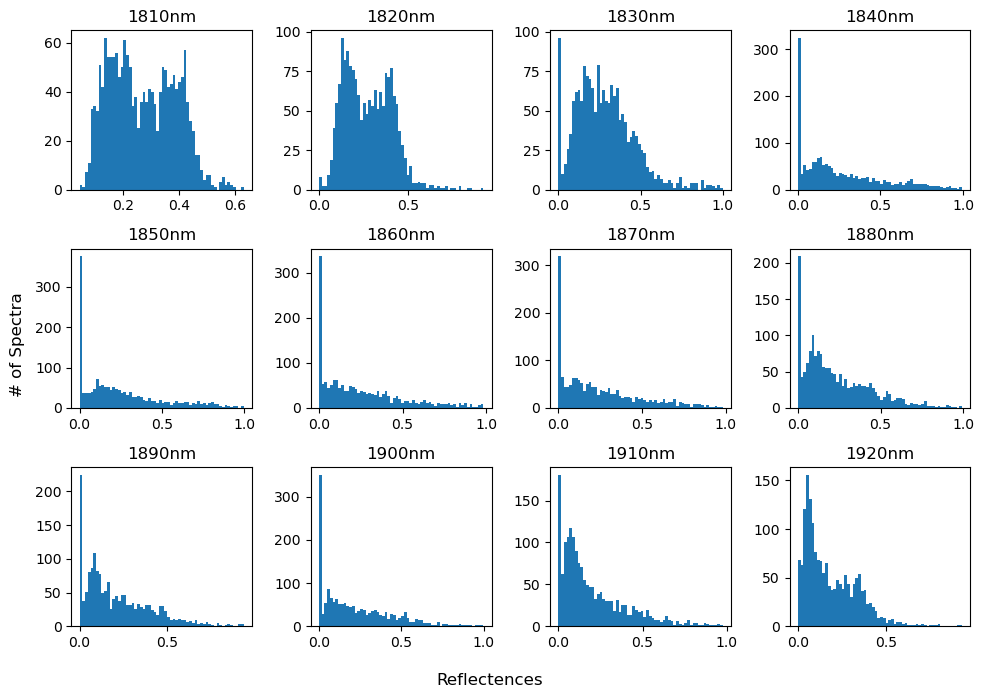

In [20]:
# Create a 2x2 grid of subplots
start = 1810
spectra = [str(i) for i in range(start, start+10*12, 10)]
n_plots = len(spectra)
# row = int(np.ceil(np.sqrt(n_plots)))
fig, axs = plt.subplots(3, 4, figsize=(10, 7))

fig.supxlabel("Reflectences")
fig.supylabel("# of Spectra")

for i, s in enumerate(spectra):
    px = i % 4
    py = i // 4
    axs[py, px].hist(nr400to2490[s], bins=60)
    axs[py, px].set_title(s+'nm')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Finally 2490nm 

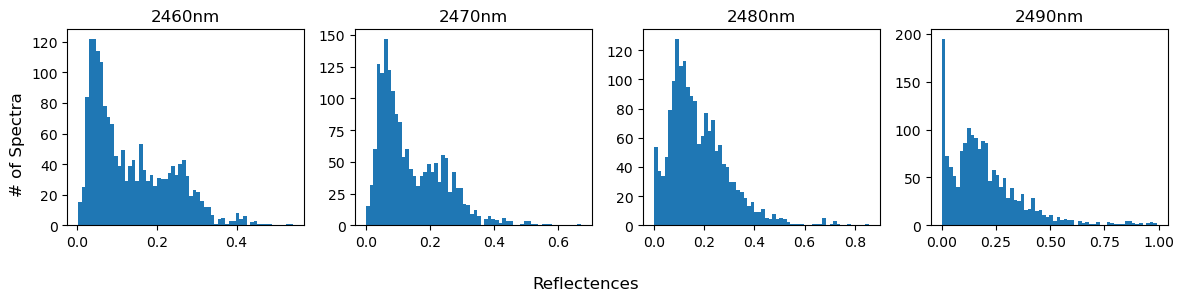

In [21]:
# Create a 2x2 grid of subplots
start = 2460
spectra = [str(i) for i in range(start, start+10*4, 10)]
n_plots = len(spectra)
fig, axs = plt.subplots(1, n_plots, figsize=(12, 3))

fig.supxlabel("Reflectences")
fig.supylabel("# of Spectra")

for i, s in enumerate(spectra):
    axs[i].hist(nr400to2490[s],bins=60)
    axs[i].set_title(s+'nm')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Around 700 points have these near zero anomalies.

### Duplicate Datapoint
The duplicates are:
```
QUE_T1.11.A (index 517)
QUE_T1.11.H (index 524)
```
Here is a simple check on just one wavelength, that reveals the two datapoints. One can visualy inspect them to confirm that they are indeed equal on all fields. 

There are no other duplicates.

In [ ]:
data = df['400']
for i in range(data.shape[0]):
    for j in range(i+1, data.shape[0]):
        if data[i] == data[j] and i!=j:
            print(df['Spectra'][i], i)

QUE_T1.11.A 517
QUE_T1.11.H 524


In [16]:
(df.iloc[517] == df.iloc[524]).sum() # matches on 216 of the 217 columns (all but the name)

np.int64(216)

### The Anomalies

Closer inspection of anomalous spectra. (spectra with a sudden and out of line zero value)



In [23]:
anomalies_i = [i for i in range(nr400to2490.shape[0]) if nr400to2490.iloc[i].min()==0]
complementary_indices = nr400to2490.index.difference(anomalies_i)
len(anomalies_i)

442

In [24]:
anomalies = df.iloc[anomalies_i]
non_anomalies = df.iloc[complementary_indices]

/var/folders/8m/2xtf2jw17lb35znwjpyxlhhr0000gn/T/ipykernel_41602/457675451.py:3: RuntimeWarning: divide by zero encountered in log
  helper_functions.simple_histogram(np.log(mins).clip(-40, 100), bins=100,  x_label='log of the minimums', y_label='count', title='logged minimums of datapoints (-40 are the zeros)',)
/var/folders/8m/2xtf2jw17lb35znwjpyxlhhr0000gn/T/ipykernel_41602/457675451.py:3: RuntimeWarning: invalid value encountered in log
  helper_functions.simple_histogram(np.log(mins).clip(-40, 100), bins=100,  x_label='log of the minimums', y_label='count', title='logged minimums of datapoints (-40 are the zeros)',)


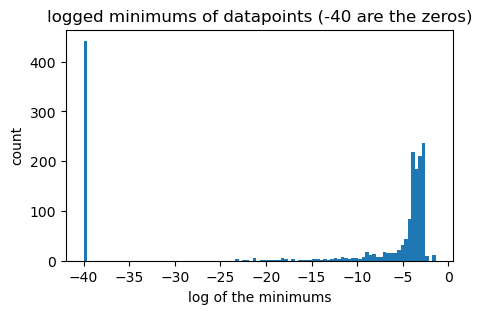

In [27]:
#| output: false
mins = np.fromiter((nr400to2490.iloc[i].min() for i in range(nr400to2490.shape[0])), dtype=float)
helper_functions.simple_histogram(np.log(mins).clip(-40, 100), bins=100,  x_label='log of the minimums', y_label='count', title='logged minimums of datapoints (-40 are the zeros)',)

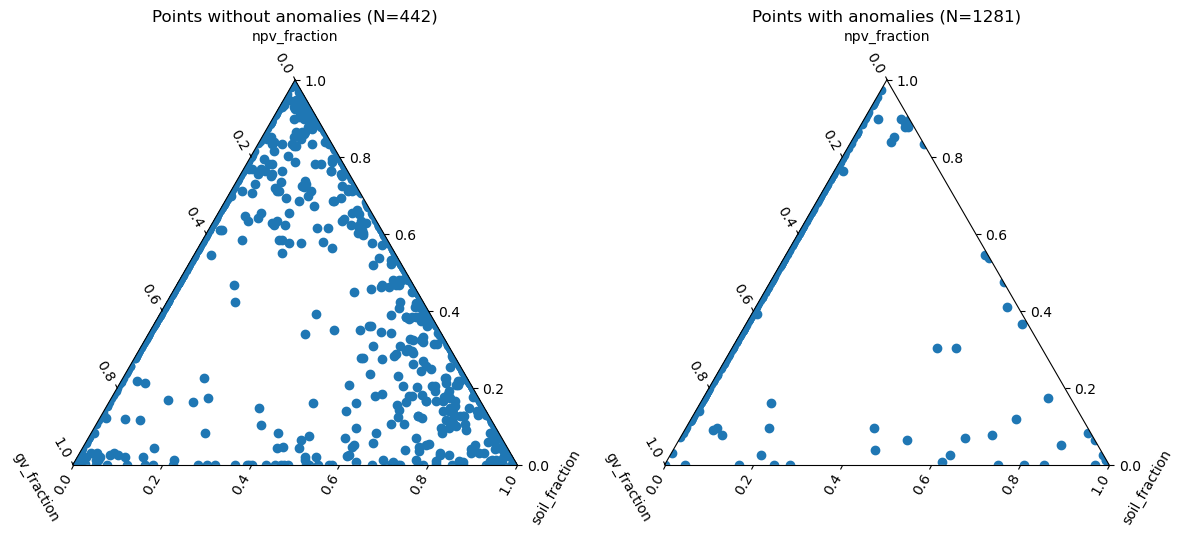

In [28]:
fig, axs = plt.subplots(1, 2, 
    figsize=(14, 5), 
    subplot_kw={'projection': 'ternary'}
)

ax1 = axs[0]
pc = ax1.scatter(non_anomalies['npv_fraction'],non_anomalies['gv_fraction'],non_anomalies['soil_fraction'])
ax1.set_tlabel('npv_fraction')
ax1.set_llabel('gv_fraction')
ax1.set_rlabel('soil_fraction')
ax1.set_title(f'Points without anomalies (N={len(anomalies_i)})')

ax2 = axs[1]
pc = ax2.scatter(anomalies['npv_fraction'],anomalies['gv_fraction'],anomalies['soil_fraction'])
ax2.set_tlabel('npv_fraction')
ax2.set_llabel('gv_fraction')
ax2.set_rlabel('soil_fraction')
ax2.set_title(f'Points with anomalies (N={nr400to2490.shape[0] - len(anomalies_i)})')
plt.show()

# Dataset Sources

Our dataset comes from 6 separate studies.

In [34]:
df = helper_functions.open_file(DATA_FILEPATH)
fractions, nr900to1700 = helper_functions.take_subset(df, 900, 1700)
source_fields = list(set(df['reference_for_original_field_spectra']))

In [35]:
names = {
    "Numata" : 'Numata, I.; Roberts, D.A.; Chadwick, O.A.; Schimel, J.P.; Galvão, L.S.; Soares, J.V. Evaluation of hyperspectral data for pasture estimate in the Brazilian Amazon using field and imaging spectrometers. Remote Sensing of Environment 2008, 112, 1569–1583. https://doi.org/10.1016/j.rse.2007.08.014.',
    "Roth": 'Roth, K. Discriminating Among Plant Species and Functional Types Using Spectroscopy Data: Evaluating Capabilities Within and Across Ecosystems, Across Spatial Scales and Through Seasons, University of California Santa Barbara, 2014.',
    "Roberts": 'Roberts, D.; Brown, K.; Green, R.; Ustin, S.; Hinckley, T. Investigating the Relationship Between Liquid Water and Leaf Area in Clonal Populus. In Proceedings of the Summaries of the Seventh JPL Airborne Earth Science Workshop; Jet Propulsion Lab: Pasadena, 1998.',
    "Quemada": 'Quemada, M.; Daughtry, C.S.T. Spectral Indices to Improve Crop Residue Cover Estimation under Varying Moisture Conditions. Remote Sensing 2016, 8, 660. https://doi.org/10.3390/rs8080660.',
    "Daughtry" : 'Daughtry, C.S.T.; Hunt, E.R. Mitigating the effects of soil and residue water contents on remotely sensed estimates of crop residue cover. Remote Sensing of Environment 2008, 112, 1647–1657. https://doi.org/10.1016/j.rse.2007.08.006.'
}

In [36]:
Roberts = df[names['Roberts'] == df['reference_for_original_field_spectra']]
unnamed = df[df['reference_for_original_field_spectra'].isna()]
Numata = df[names['Numata'] == df['reference_for_original_field_spectra']]
Quemada = df[names['Quemada'] == df['reference_for_original_field_spectra']]
Roth = df[names['Roth'] == df['reference_for_original_field_spectra']]
Daughtry = df[names['Daughtry'] == df['reference_for_original_field_spectra']]

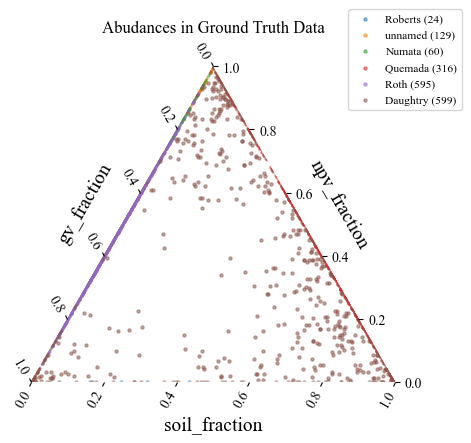

In [38]:
mpl.rcParams['font.family'] = ['Times New Roman']

fig = plt.figure(figsize=(10.8, 4.8))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)
ax = fig.add_subplot(1, 2, 1, projection="ternary")
for spine in ax.spines.values():
    # spine.set_alpha(0.5)
    spine.set_visible(False)
# ax.margins(0.1)

point_size = 5

ax.scatter(Roberts['npv_fraction'],Roberts['gv_fraction'],Roberts['soil_fraction'], s=point_size, alpha=0.5, marker='o', label=f"Roberts ({Roberts.shape[0]})")
ax.scatter(unnamed['npv_fraction'],unnamed['gv_fraction'],unnamed['soil_fraction'], s=point_size , alpha=0.5, marker='o', label=f"unnamed ({unnamed.shape[0]})")
ax.scatter(Numata['npv_fraction'],Numata['gv_fraction'],Numata['soil_fraction'], s=point_size , alpha=0.5, marker='o', label=f"Numata ({Numata.shape[0]})")
ax.scatter(Quemada['npv_fraction'],Quemada['gv_fraction'],Quemada['soil_fraction'], s=point_size , alpha=0.5, marker='o', label=f"Quemada ({Quemada.shape[0]})")
ax.scatter(Roth['npv_fraction'],Roth['gv_fraction'],Roth['soil_fraction'], s=point_size ,alpha=0.5, marker='o', label=f"Roth ({Roth.shape[0]})")
ax.scatter(Daughtry['npv_fraction'],Daughtry['gv_fraction'],Daughtry['soil_fraction'], s=point_size , alpha=0.5, marker='o', label=f"Daughtry ({Daughtry.shape[0]})")

position = 'tick1'
ax.set_tlabel('npv_fraction', fontsize=14)
ax.set_llabel('gv_fraction', fontsize=14)
ax.set_rlabel('soil_fraction', fontsize=14)

ax.taxis.set_label_position(position)
ax.laxis.set_label_position(position)
ax.raxis.set_label_position(position)

t_text = ax.taxis.label
l_text = ax.laxis.label
r_text = ax.raxis.label

ax.legend(loc='upper right', fontsize='small', bbox_to_anchor=(0.2, 0.2, 1, 1))

ax.set_title('Abudances in Ground Truth Data')

ax = plt.gca()
ax.margins(0.15)
plt.show()

# Correlations

Correlation of wavelengths to each other is useful for estimating information contained in each wavelength.

In [12]:
def linear_regression_check(a: pd.DataFrame, b: pd.DataFrame):
    """
    Return the r^2 correlation coefficient between two wavelengths.
    The input wavelengths are stored as 1 column dataframes.
    """
    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(a, b)
    return r_value**2

In [15]:
# Takes 13 seconds for 210x210
correlations = []
dataset = nr900to1700
for wi, i in enumerate(dataset.columns):
    layer = []
    for wj, j in enumerate(dataset.columns):
        a = dataset[i]
        b = dataset[j]
        layer.append(linear_regression_check(a, b))
    correlations.append(layer)


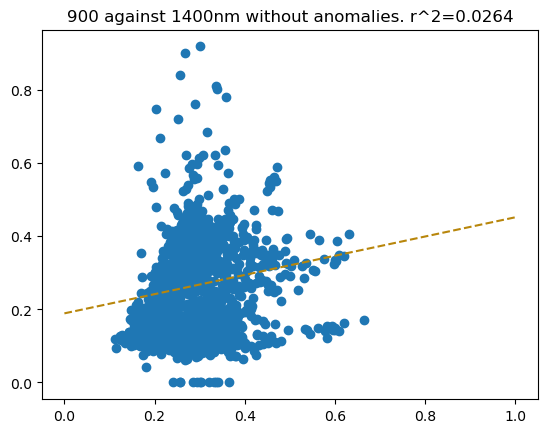

In [16]:
# snippet for inspecting the relationship between wavelengths
a_wavelength = '900'
b_wavelength = '1400'
a = nr400to2490[a_wavelength]
b = nr400to2490[b_wavelength]
plt.scatter(a, b)

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(a, b)
plt.title(f'{a_wavelength} against {b_wavelength}nm without anomalies. r^2={round(r_value**2,4)}')
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept
plt.plot(
    x_fit,
    y_fit,
    color='darkgoldenrod',
    linestyle='--',
    zorder=3)

plt.show()

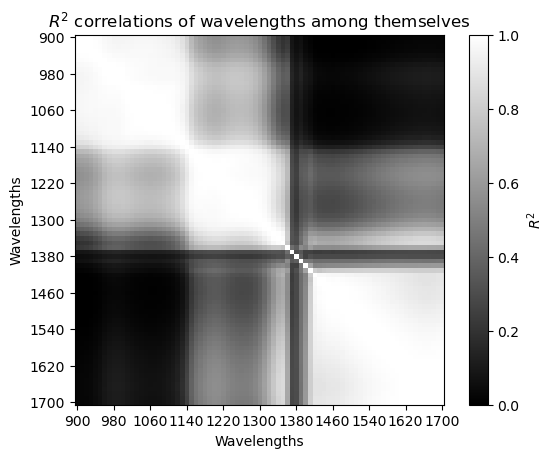

In [20]:
fig, ax = plt.subplots()

img = ax.imshow(correlations, vmin=0, cmap='gray')

ax.set_title("$R^2$ correlations of wavelengths among themselves")
ax.set_xlabel("Wavelengths")
ax.set_ylabel("Wavelengths")
tick_locations = np.arange(0, 81, 8)
tick_labels = [nr900to1700.columns[i] for i in tick_locations]
ax.set_xticks(tick_locations, tick_labels)
ax.set_yticks(tick_locations, tick_labels)

cbar = fig.colorbar(img, ax=ax, label='$R^2$')
plt.savefig("lab_data_wavelength_correlations.svg", format="svg")
plt.show()

# Atmospheric Data
Characterization of the data provided to us by the modelling team. Modelled data was based on lab data.

In [18]:
df = helper_functions.open_file(ATMO_DATA)
fractions, at900to1690 = helper_functions.take_subset(df,start=900,end=1690)
vza = df["VZA"]

In [19]:
at900to1690.shape

(144, 80)

Histogram of npv abundancs. Lab data has only npv and soil, hence it is better to represent as npv abundance histogram. (Note that these abundances were selected purposefully by the atmospheric modelling team.)

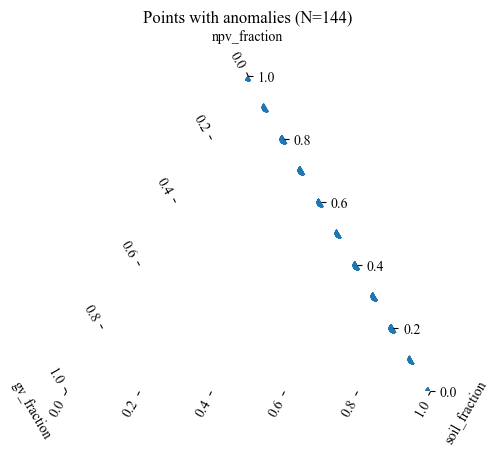

In [37]:
mpl.rcParams['font.family'] = ['Times New Roman']
fig = plt.figure(figsize=(10.8, 4.8))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)
ax = fig.add_subplot(1, 2, 1, projection="ternary")

for spine in ax.spines.values():
    spine.set_visible(False)

pc = ax.scatter(fractions["npv_fraction"], fractions["gv_fraction"], fractions["soil_fraction"])
ax.set_tlabel('npv_fraction')
ax.set_llabel('gv_fraction')
ax.set_rlabel('soil_fraction')
ax.set_title(f'Points with anomalies (N={at900to1690.shape[0]})')
plt.show()

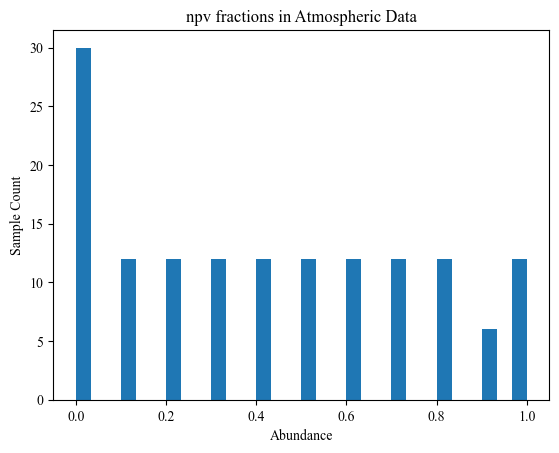

In [ ]:
npv_fraction = fractions['npv_fraction']
plt.hist(npv_fraction, bins=30)
plt.title("npv fractions in Atmospheric Data")
plt.xlabel("Abundance")
plt.ylabel("Sample Count")
plt.show()

Here is a heatmap similar to the heatmap shown for the lab data. 

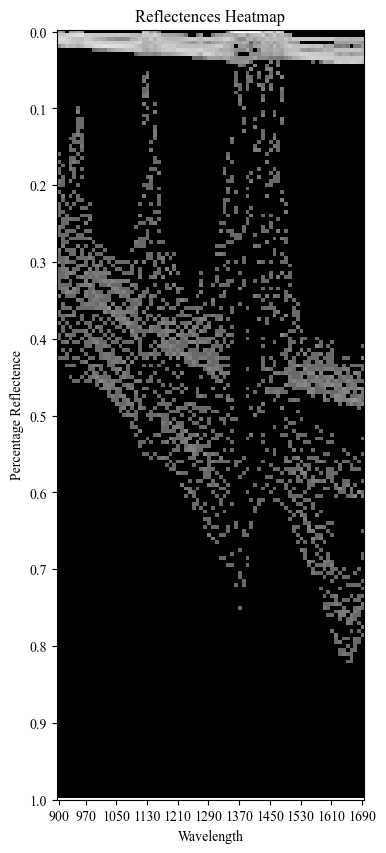

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
dataset = at900to1690
resolution = 200
def contrast(array, coef=5):
    return array ** (1/coef)
start = 0
end = resolution
xticks = dataset.columns
bins = [1/resolution*i for i in range(0,end+1)]
l = [contrast(np.histogram(dataset[s], bins=bins)[0]) for s in xticks]
np_formatted_l = np.rot90(np.fliplr(np.vstack(l)))

ax.imshow(np_formatted_l, vmin=0, cmap='gray')

ax.set_title("Reflectences Heatmap")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Percentage Reflectence")

n_ticks = 11
idx = np.linspace(0, len(xticks)-1, n_ticks, dtype=int)
ticks = xticks[idx]
plt.xticks(idx, ticks)
idx = np.linspace(0, end, n_ticks, dtype=int)
yticks = idx / resolution
plt.yticks(idx, yticks)

plt.show()

Correlations of individual wavelengths with npv_fraction.

In [25]:
import sklearn  # TODO switch to scipy later
# TODO talk about normalization and dimensional reduction attempts

As you might observe, there is almost no correlation of the reflectances to the abundances.

In [29]:
dataset = at900to1690
for wavelength in dataset.columns:
    reg = sklearn.linear_model.LinearRegression()
    reg.fit(dataset[wavelength].to_numpy().reshape(-1, 1), fractions["npv_fraction"])
    r2 = reg.score(dataset[wavelength].to_numpy().reshape(-1, 1), fractions["npv_fraction"])
    print(f"{wavelength}nm r^2={r2}")

900nm r^2=0.007063215663027811
910nm r^2=0.007352930150617554
920nm r^2=0.008148088915143625
930nm r^2=0.007581197728636968
940nm r^2=0.0074848716094251255
950nm r^2=0.006892182159447979
960nm r^2=0.007303566161535824
970nm r^2=0.00828126829558995
980nm r^2=0.00824876719161094
990nm r^2=0.008091897538714199
1000nm r^2=0.007889011660660139
1010nm r^2=0.007737139931127346
1020nm r^2=0.00782413355499878
1030nm r^2=0.00775249911802911
1040nm r^2=0.008060381022176766
1050nm r^2=0.008068859544243412
1060nm r^2=0.008201792892415072
1070nm r^2=0.007898984010264787
1080nm r^2=0.0077412800148490835
1090nm r^2=0.007955093386322276
1100nm r^2=0.007711816516451253
1110nm r^2=0.007511857895727836
1120nm r^2=0.0059680288658332525
1130nm r^2=0.005635574385515318
1140nm r^2=0.007321640663107476
1150nm r^2=0.006496316896066223
1160nm r^2=0.007451495209992665
1170nm r^2=0.007933685055344863
1180nm r^2=0.0075953499636695065
1190nm r^2=0.007814825432167494
1200nm r^2=0.007727844841663334
1210nm r^2=0.00798

Correlations

In [21]:
correlations = []
dataset = at900to1690
for c1 in dataset.columns:
    cors = []
    for c2 in dataset.columns:
        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(dataset[c1], dataset[c2])
        cors.append(r_value**2)
    correlations.append(cors)

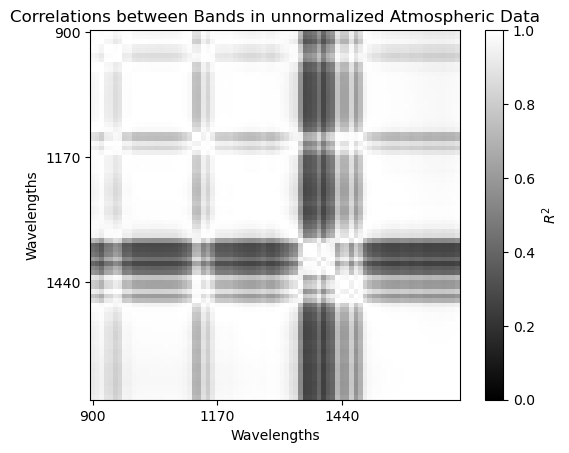

In [22]:
fig, ax = plt.subplots()

img = ax.imshow(correlations, vmin=0, cmap='gray')

ax.set_title("Correlations between Bands in unnormalized Atmospheric Data")
ax.set_xlabel("Wavelengths")
ax.set_ylabel("Wavelengths")
tick_locations = np.arange(0, dataset.shape[1], 27)
tick_labels = [dataset.columns[i] for i in tick_locations]
ax.set_xticks(tick_locations, tick_labels)
ax.set_yticks(tick_locations, tick_labels)

cbar = fig.colorbar(img, ax=ax, label='$R^2$')
plt.savefig("atmo_data_correlations.svg", format="svg")
plt.show()

## VZA

In [25]:
vza_color_map = {
    0.0 : "blue",
    10.0 : "green",
    20.0 : "yellow",
    25.0 : "orange",
    30.0 : "darkorange",
    40.0 : "red",
}

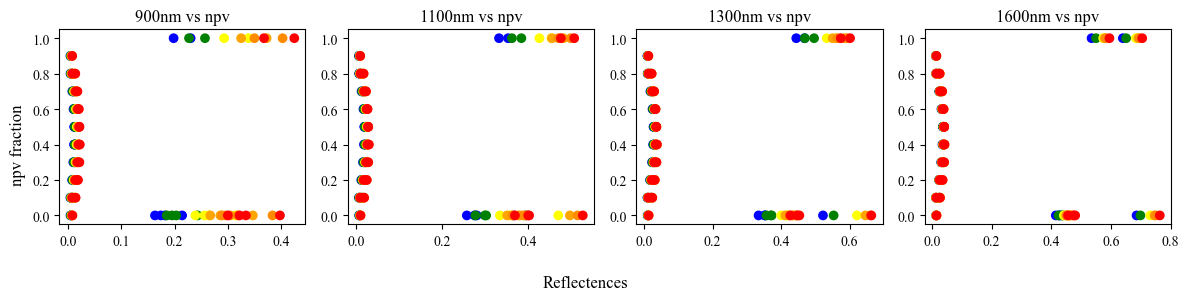

In [28]:
wavelengths = ["900", "1100", "1300", "1600"]
n_plots = len(wavelengths)
plt.rcParams["font.family"] = "Times New Roman"
fig, axs = plt.subplots(1, n_plots, figsize=(3*n_plots, 3))
fig.supxlabel("Reflectences")
fig.supylabel("npv fraction")

for i, wavelength in enumerate(wavelengths):
    axs[i].scatter(at900to1690[wavelength].to_numpy().reshape(-1, 1), fractions["npv_fraction"], c=[
        vza_color_map[v] for v in vza
    ])
    axs[i].set_title(f"{wavelength}nm vs npv")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

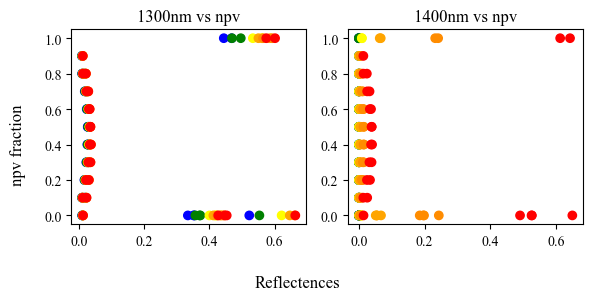

In [31]:
wavelengths = ["1300", "1400"]
n_plots = len(wavelengths)
plt.rcParams["font.family"] = "Times New Roman"
fig, axs = plt.subplots(1, n_plots, figsize=(3*n_plots, 3))
fig.supxlabel("Reflectences")
fig.supylabel("npv fraction")

for i, wavelength in enumerate(wavelengths):
    axs[i].scatter(at900to1690[wavelength].to_numpy().reshape(-1, 1), fractions["npv_fraction"], c=[
        vza_color_map[v] for v in vza
    ])
    axs[i].set_title(f"{wavelength}nm vs npv")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("atmo_data_unnormalized_npv_wavelength_plots.svg", format="svg")
plt.show()

# Conclusions

Other members of the team were notified about the basic information and anomalies in the dataset. They either made sure the anomalous ranges were excluded form the training, or ensured the anomalies weren't affecting the results.

The wavelength correlations were later reused to attempt dimensional reduction.
